In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("SOFRRRP.csv")
df.head()

Saving SOFRRRP.csv to SOFRRRP.csv


,Date,SOFR,RRP
0,3/4/2021,0.0200,0.0000
1,3/5/2021,0.0200,0.0000
2,3/8/2021,0.0200,0.0000
3,3/9/2021,0.0200,0.0000
4,3/10/2021,0.0200,0.0000


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

In [6]:
df["Spread"] = df["SOFR "] - df["RRP"]

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [8]:
benchmark = df[(df["Day"] >= 21) & (df["Day"] <= 25)]

benchmark_avg = (
    benchmark
    .groupby(["Year","Month"])["Spread"]
    .mean()
    .reset_index()
)

benchmark_avg.rename(columns={"Spread":"Benchmark_Spread"}, inplace=True)

In [9]:
month_end = df.groupby(["Year","Month"]).tail(1)

month_end = month_end[["Year","Month","Spread"]]

month_end.rename(columns={"Spread":"MonthEnd_Spread"}, inplace=True)

In [10]:
seasonality = pd.merge(benchmark_avg, month_end, on=["Year","Month"])

In [11]:
seasonality["Spike"] = (
    seasonality["MonthEnd_Spread"]
    - seasonality["Benchmark_Spread"]
)

In [17]:
seasonality.head(20)

,Year,Month,Benchmark_Spread,MonthEnd_Spread,Spike
0,2021,3,0.0100,0.0100,0.0000
1,2021,4,0.0100,0.0100,0.0000
2,2021,5,0.0100,0.0100,0.0000
3,2021,6,0.0000,0.0000,0.0000
4,2021,7,0.0000,0.0000,0.0000
5,2021,8,0.0000,0.0000,0.0000
6,2021,9,0.0000,0.0000,0.0000
7,2021,10,-0.0100,0.0000,0.0100
8,2021,11,0.0000,0.0000,0.0000
9,2021,12,0.0000,0.0000,0.0000


In [15]:
avg_spike = seasonality["Spike"].mean()

print("Average Month-End SOFR Spike:", avg_spike)

Average Month-End SOFR Spike: 0.03901388888888892


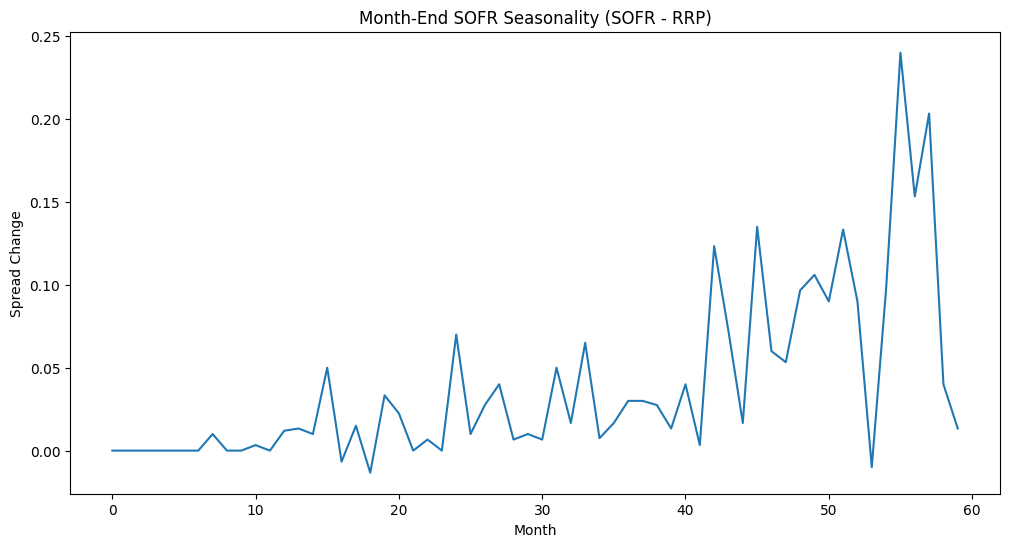

In [14]:
plt.figure(figsize=(12,6))

plt.plot(seasonality["Spike"])

plt.title("Month-End SOFR Seasonality (SOFR - RRP)")
plt.ylabel("Spread Change")
plt.xlabel("Month")

plt.show()

In [16]:
seasonality.sort_values("Spike", ascending=False).head(10)

,Year,Month,Benchmark_Spread,MonthEnd_Spread,Spike
55,2025,10,0.2300,0.4700,0.2400
57,2025,12,0.1667,0.3700,0.2033
56,2025,11,0.2167,0.3700,0.1533
45,2024,12,0.1050,0.2400,0.1350
51,2025,6,0.0667,0.2000,0.1333
42,2024,9,0.0367,0.1600,0.1233
49,2025,4,0.0540,0.1600,0.1060
54,2025,9,0.1425,0.2400,0.0975
48,2025,3,0.0633,0.1600,0.0967
50,2025,5,0.0100,0.1000,0.0900
